# Numpy 및 통계
## 3장. 통계 기초

In [1]:
import pandas as pd
import numpy as np

##### 학생 성적 데이터 읽기

In [2]:
# 데이터 읽기

# DataFrame의 출력을 소수점 이하 3자리로 제한
pd.set_option('display.precision', 3)    # 기본값 : 6

df = pd.read_csv('data/scores.csv', index_col='student')
print(df.head())

         english  mathematics
student                      
1             42           65
2             69           80
3             56           63
4             41           63
5             57           76


In [3]:
# 10명의 영어 점수를 scores_eng 배열에 저장
scores_eng = np.array(df['english'])[:10]
print(scores_eng)

[42 69 56 41 57 48 65 49 65 58]


In [4]:
# 데이터 프레임 scores_df 생성
index_labels = ['A','B','C','D','E','F','G','H','I','J']
scores_df = pd.DataFrame({'score':scores_eng},
                         index=index_labels)
scores_df.index.name='student'
print(scores_df)

         score
student       
A           42
B           69
C           56
D           41
E           57
F           48
G           65
H           49
I           65
J           58


##### 데이터 중심의 지표 : 평균

In [5]:
# 평균값 : np.mean(array)

# 기본 방법
print(sum(scores_eng) / len(scores_eng))    # = 전체합 / n

# Numpy의 mean()
print(np.mean(scores_eng))

# DataFrame의 mean()
print(scores_df.mean())

55.0
55.0
score    55.0
dtype: float64


##### 데이터 중심 지표 : 중앙값 계산

In [6]:
# 파이썬 사용

sorted_scores = np.sort(scores_eng)    # 중앙값은 오름차순으로 정렬 먼저!
print(f'sorted_scores: {sorted_scores}')

n = len(sorted_scores)
if n % 2==0:
    m0 = sorted_scores[n//2-1]    # 인덱스가 [0]부터 시작하므로 1 빼줌
    m1 = sorted_scores[n//2]
    median = (m0 + m1) / 2
else:
    median = sorted_scores[(n+1)//2-1]

print(f'median: {median}')

# 데이터 개수가 짝수개 이면 중앙값은 데이터 내부에 존재하지 않는다.
# 56.5 => 실제 데이터의 값은 아님

sorted_scores: [41 42 48 49 56 57 58 65 65 69]
median: 56.5


In [7]:
# Numpy의 median() 함수 사용

# Numpy의 median()
print(f'np.median(): {np.median(scores_eng)}')

np.median(): 56.5


##### 데이터 중심 지표 : 최빈값(scipy 사용)

In [8]:
from scipy import stats

a = np.array([1,1,2,3,3,3,3,4,4,5])
mode_result = stats.mode(a)
print(f'최빈값: {mode_result.mode}')
print(f'최빈값 빈도수: {mode_result.count}')

# 10명의 영어 점수 중 최빈값 및 빈도수
result = stats.mode(scores_eng)
print(f'최빈값: {result.mode}, 빈도수: {result.count}')

최빈값: 3
최빈값 빈도수: 4
최빈값: 65, 빈도수: 2


##### 데이터 중심 지표 : 최빈값(numpy 사용)

In [9]:
# Numpy의 unique() 메소드 사용
# np.unique(data, return_counts=True)

# return_counts : 각 숫자의 빈도수 리턴
values, counts = np.unique(scores_eng, return_counts=True)

print(f'values: {values}')
print(f'counts: {counts}')

index = np.argmax(counts)    # 각 숫자의 발생 빈도수 중 최대값의 index 계산

print(f'최빈값: {values[index]}, 빈도수: {counts[index]}')

values: [41 42 48 49 56 57 58 65 69]
counts: [1 1 1 1 1 1 1 2 1]
최빈값: 65, 빈도수: 2


In [10]:
# DataFrame, Series의 mode() 메소드 사용
# 최빈값 계산

print(scores_df.mode().values)
print(scores_df.value_counts())

[[65]]
score
65       2
41       1
42       1
49       1
48       1
56       1
57       1
58       1
69       1
Name: count, dtype: int64


##### 데이터 산포도 : 편차

In [11]:
# 편차 : 각 데이터가 평균으로부터 떨어져 있는 정도
# 각 학생의 성적 편차

mean_value = np.mean(scores_eng)
deviation = scores_eng - mean_value    # Broadcast 적용
print(f'평균: {mean_value}')
print(f'편차: {deviation}')

평균: 55.0
편차: [-13.  14.   1. -14.   2.  -7.  10.  -6.  10.   3.]


In [12]:
# DataFrame에 편차(deviation) 컬럼 추가

summary_df = scores_df.copy()    # 새로운 Dataframe 생성(복제본)
summary_df['deviation'] = deviation    # 새로운 컬럼 deviation

print(summary_df)
print(summary_df.mean())    # score, deviation의 편차 확인

         score  deviation
student                  
A           42      -13.0
B           69       14.0
C           56        1.0
D           41      -14.0
E           57        2.0
F           48       -7.0
G           65       10.0
H           49       -6.0
I           65       10.0
J           58        3.0
score        55.0
deviation     0.0
dtype: float64


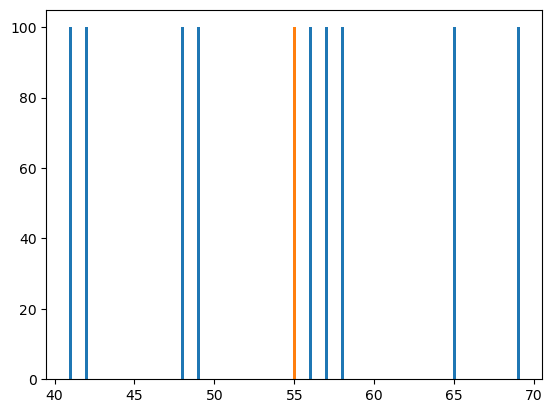

In [13]:
# 편차 확인

import matplotlib.pyplot as plt

plt.bar(scores_eng, 100, width=0.2)
plt.bar(mean_value, 100, width=0.2)    # 주황색 그래프
plt.show()

In [14]:
# 편차의 평균 : 항상 0

print(f'편차 평균: {np.mean(deviation)}')

편차 평균: 0.0


##### 데이터 산포도 지표 : 분산

In [15]:
# Numpy의 분산 : np.var(array) 사용

var1 = np.mean(deviation ** 2)    # mean(편차^2)
print(var1)

# Numpy의 var() 사용
var2 = np.var(scores_eng)    # ddof = 0이 기본값
print(var2)

86.0
86.0


In [16]:
# Pandas 분산

# Pandas의 var()은 불편 분산 사용
print(scores_df.var(ddof=0))    # 모 분산
print(scores_df.var())    # 불편 분산(기본값 : ddof = 1)

score    86.0
dtype: float64
score    95.556
dtype: float64


##### 데이터 산포도 지표 : 표준편차

In [17]:
# Numpy를 이용한 표준 편차 계산 : np.std(array)

var1 = np.var(scores_eng)    # 분산
std_dev1 = np.sqrt(var1)    # 분산에 제곱근
print(f'표준편차: {std_dev1:.3f}')

# numpy의 std() 메소드 사용
std_dev2 = np.std(scores_eng)
print(f'표준편차: {std_dev2:.3f}')

표준편차: 9.274
표준편차: 9.274


##### 데이터 산포도 지표 : 사분위 범위

In [18]:
# 범위(range)

print(np.max(scores_eng) - np.min(scores_eng))

28


##### 데이터 산포도 지표 : 사분위수 및 IQR 계산

In [19]:
# np.percentile(array, percentage): array에서 주어진 백분위수(percentage) 계산

scores_Q1 = np.percentile(scores_eng, 25)
scores_Q2 = np.percentile(scores_eng, 50)    # => 중앙값
scores_Q3 = np.percentile(scores_eng, 75)
print(f'Q1: {scores_Q1}, Q2: {scores_Q2}, Q3: {scores_Q3}')

score_IQR = scores_Q3 - scores_Q1
print(f'IQR: {score_IQR}')
print(f'중앙값: {scores_Q2}')

Q1: 48.25, Q2: 56.5, Q3: 63.25
IQR: 15.0
중앙값: 56.5


In [20]:
# pandas의 describe() 사용 : 요약 정보 확인

desc = scores_df.describe()
print(desc)
print(desc.loc['25%'].values[0])    # 뒤의 values[0]은 없이 출력하면
print(desc.loc['50%'].values[0])    # [[값]] 이렇게 출력되므로
print(desc.loc['75%'].values[0])    # 보기 편하게 넣어준 것. 값 자체만 필요하면 굳이 필요 없음

        score
count  10.000
mean   55.000
std     9.775
min    41.000
25%    48.250
50%    56.500
75%    63.250
max    69.000
48.25
56.5
63.25


##### 예제 : 사분위수 및 백분위수 계산

In [21]:
## 데이터 예시 (시험 점수)
scores = np.array([45,52,58,62,65,68,72,75,78,82,85,88,91,94,98])

''' 5-수치 요약 : 최솟값, Q1, 중앙값, Q3, 최댓값 '''
min_val = np.min(scores)
q1 = np.percentile(scores,25)
median = np.median(scores)
q3 = np.percentile(scores, 75)
max_val = np.max(scores)

print('=== 5-수치 요약===')
print(f'최소값: {min_val}')
print(f'Q1(25%): {q1}')
print(f'중앙값: {median}')
print(f'Q3(75%): {q3}')
print(f'최대값: {max_val}')

# 다양한 백분위수 계산
percentiles = [10,25,50,75,90,95,100]
print('\n=== 백분위수 ===')
for p in percentiles:
    val = np.percentile(scores, p)
    print(f'{p}번째 백분위수: {val:.2f}')

=== 5-수치 요약===
최소값: 45
Q1(25%): 63.5
중앙값: 75.0
Q3(75%): 86.5
최대값: 98

=== 백분위수 ===
10번째 백분위수: 54.40
25번째 백분위수: 63.50
50번째 백분위수: 75.00
75번째 백분위수: 86.50
90번째 백분위수: 92.80
95번째 백분위수: 95.20
100번째 백분위수: 98.00


##### 예제 : 사분위수를 이용한 boxplot 시각화

IQR: 23.0
Q3+1.5IQR:  121.0
Q1-1.5IQR:  29.0


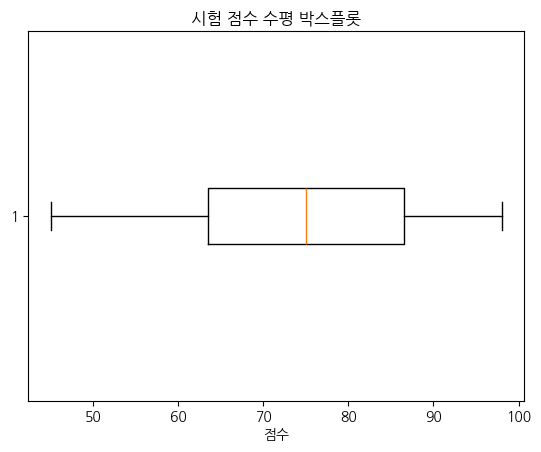

In [22]:
import koreanize_matplotlib

q1 = np.percentile(scores, 25)
q3 = np.percentile(scores, 75)
iqr = q3 - q1

print('IQR:', iqr)
print('Q3+1.5IQR: ', q3 + (1.5*iqr))
print('Q1-1.5IQR: ', q1 - (1.5*iqr))

# 수평 박스플롯
plt.boxplot(scores, vert=False)
plt.title('시험 점수 수평 박스플롯')
plt.xlabel('점수')
plt.show()

##### 정규화 예제 #1

In [23]:
# 샘플 데이터 (학생 점수)
scores = np.array([65,70,75,80,85,90,95,100])
print(f'원본 데이터: {scores}')

# Min-Max 정규화
min_val = np.min(scores)
max_val = np.max(scores)
min_max = (scores - min_val) / (max_val - min_val)    # => 브로드캐스팅
print(f'min-max 정규화 결과: {np.round(min_max, 3)}')
print(f'min-max 정규화 범위: [{np.min(min_max):.3f}, {np.max(min_max):.3f}]')

# Z-score 표준화
mean_val = np.mean(scores)
std_val = np.std(scores)
z_score = (scores - mean_val) / std_val    # => 브로드캐스팅
print(f'z-score 표준화 결과: {np.round(z_score, 3)}')
print(f'z-score 평균: {np.mean(z_score):.3f}')
print(f'z-score 표준편차: {np.std(z_score):.3f}')

원본 데이터: [ 65  70  75  80  85  90  95 100]
min-max 정규화 결과: [0.    0.143 0.286 0.429 0.571 0.714 0.857 1.   ]
min-max 정규화 범위: [0.000, 1.000]
z-score 표준화 결과: [-1.528 -1.091 -0.655 -0.218  0.218  0.655  1.091  1.528]
z-score 평균: 0.000
z-score 표준편차: 1.000


##### 정규화 예제 #2

In [24]:
# 2차원 데이터(학생별 과목 점수)
#               수학, 토익, 나이
data = np.array([[80,620, 25],
                [75,950,23],
                [90,560,25],
                [85,750,22]])
print('원본데이터:')
print('수학 토익 나이')
print(data)
print(f'각 컬럼의 범위 : {np.max(data, axis=0)-np.min(data,axis=0)}')

# 컬럼별 Min-Max 정규화
data_normalized = np.zeros_like(data, dtype=float)
for col in range(data.shape[1]):
    col_min = np.min(data[:, col])
    col_max = np.max(data[:, col])
    data_normalized[:,col] = (data[:,col] - col_min)/(col_max -  col_min)

print('\n Min-Max 정규화 후:')
print(data_normalized)

# 열별 Z-score 표준화
# np.zeros_like(array):
# 주어진 배열과 동일한 모양 및 데이터 타입을 가진 배열
# 생성(0으로 초기화)
z_score = np.zeros_like(data, dtype=float)
for col in range(data.shape[1]):
    col_mean = np.mean(data[:,col])
    col_std = np.std(data[:,col])
    z_score[:,col] = (data[:,col] - col_mean) / col_std

print('\n Z-score 정규화 후:')
print(z_score)

# 각 열의 평균과 표준편차 확인
print(f'\n표준화 후 각 열의 평균: {np.mean(z_score, axis=0)}')
print(f'표준화 후 각 열의 표준편차: {np.std(z_score, axis=0)}')

원본데이터:
수학 토익 나이
[[ 80 620  25]
 [ 75 950  23]
 [ 90 560  25]
 [ 85 750  22]]
각 컬럼의 범위 : [ 15 390   3]

 Min-Max 정규화 후:
[[0.33333333 0.15384615 1.        ]
 [0.         1.         0.33333333]
 [1.         0.         1.        ]
 [0.66666667 0.48717949 0.        ]]

 Z-score 정규화 후:
[[-0.4472136  -0.66890006  0.96225045]
 [-1.34164079  1.53847014 -0.57735027]
 [ 1.34164079 -1.0702401   0.96225045]
 [ 0.4472136   0.20067002 -1.34715063]]

표준화 후 각 열의 평균: [ 1.38777878e-17 -3.46944695e-17  0.00000000e+00]
표준화 후 각 열의 표준편차: [1. 1. 1.]


##### 랜덤값 생성 : 시드 설정

In [25]:
# random.seed(value)

# 지수 표기 안함, 소수점 둘째 자리까지 출력
np.set_printoptions(precision=2, suppress=True)
# Numpy 소수점 자리수 제한 및 지수 표기법 설정
# - precision=2 : 소수점 2자리로 제한
# - suppress=True : 작은 수 지수 표기법(e-17, e+02 등) 허용 안함"

np.random.seed(1)
print(np.random.rand(4))    # 4개의 랜덤값 생성
# 3x4 크기의 배열에 랜덤값 지정
print(np.random.rand(3,4))    # 3행 4열 크기 랜덤값 생성

np.random.seed(42)
print(np.random.randint(0,100,size=5))    # 5개 랜덤값 생성

[0.42 0.72 0.   0.3 ]
[[0.15 0.09 0.19 0.35]
 [0.4  0.54 0.42 0.69]
 [0.2  0.88 0.03 0.67]]
[51 92 14 71 60]


##### 이산형 확률 분포 : 이항 분포

10회 시행 중 성공 횟수: 5
10개 세트 값: [58 42 47 45 48 46 57 46 49 42 46 48 49 50 47 56 46 58 50 53 47 59 48 54
 47 55 49 58 49 47 46 53 54 52 57 47 45 60 48 51 38 49 50 54 49 53 51 46
 49 49 52 48 45 48 48 51 56 38 48 44 53 53 53 46 60 49 50 47 59 53 43 46
 50 51 50 51 50 42 42 41 62 54 51 54 50 52 49 47 46 56 48 45 53 57 47 45
 54 51 49 47 50 52 44 53 54 54 53 52 43 56 50 60 52 46 52 56 49 44 56 43
 42 44 59 40 47 53 57 49 51 50 46 53 50 40 49 54 53 55 43 58 60 43 51 46
 55 59 41 56 50 48 49 41 47 51 52 56 53 51 53 47 51 56 49 50 52 51 48 49
 48 55 52 51 48 53 54 43 53 40 50 55 54 51 52 46 55 52 53 41 49 46 49 43
 46 51 51 55 46 55 47 52 39 47 54 46 45 53 48 50 43 47 54 53 52 54 38 57
 54 47 51 42 49 48 51 45 44 51 46 52 53 47 62 42 46 51 53 48 45 54 59 51
 44 52 51 53 53 45 50 55 46 55 48 47 53 51 45 51 50 50 44 56 56 51 50 52
 58 54 54 49 41 43 50 53 49 53 50 45 53 54 56 50 47 49 45 47 39 46 49 48
 49 55 58 40 57 44 50 50 46 55 42 56 45 48 51 53 53 51 55 45 44 50 61 43
 45 53 52 51 42 49 49 5

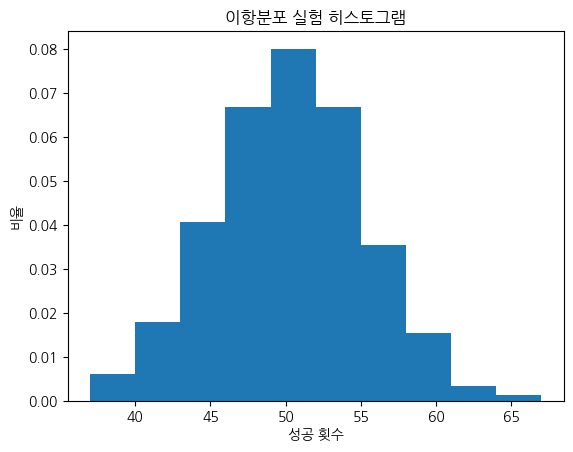

In [26]:
# 10번의 동전 던지기, 앞면(성공) 확률: 0.5, 샘플: 1세트(10회)
sample = np.random.binomial(n=10, p=0.5)
print('10회 시행 중 성공 횟수:', sample)

# 100번의 동전 던지기, 앞면(성공) 확률: 0.5, 샘플: 10세트(100번 x 10)
samples = np.random.binomial(n=100, p=0.5, size=500)    # size= 10 또는 500으로 변경
print(f'10개 세트 값: {samples}')    # 100회 수행 중 성공한 횟수를 의미

plt.hist(samples, bins=10, density=True)    # density=True : 확률밀도도 변환, 전체 면적이 1이 되도록 조정
plt.xlabel('성공 횟수')
plt.ylabel('비율')
plt.title('이항분포 실험 히스토그램')
plt.show()

##### 이산형 확률 분포 : 포아송 분포

[[2 1 3]
 [1 3 4]]


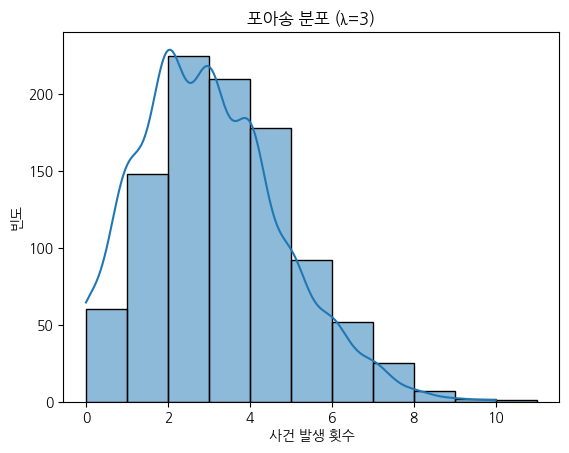

In [27]:
import seaborn as sns

sample = np.random.poisson(lam=2.5, size=(2,3))
print(sample)

# 평균 3회 발생, 1000개 샘플 생성
data2 = np.random.poisson(lam=3, size=1000)

sns.histplot(data2, bins=range(0,max(data2)+2), kde=True)
# kde : Kernel Density Estimate - 히스토그램 위에 연속 데이터의 확률 밀도, 함수를 추정하여 곡선 추가
plt.xlabel('사건 발생 횟수')
plt.ylabel('빈도')
plt.title('포아송 분포 (λ=3)')
plt.show()

##### 연속형 확률 분포 : 균등 분포

In [28]:
np.set_printoptions(precision=3, suppress=True)

a = np.random.rand(2,3)    # 2행x3열 형태, 0~1 사이의 값 랜덤 생성
print('np.random.rand(2,3)')
print(a)
print()

# np.random.uniform(): (2x3 크기 배열 생성)
b = np.random.uniform(5,10,(2,3))    # (2,3) 튜플 형태
print('np.random.uniform(5,10,(2,3))')
print(b)

np.random.rand(2,3)
[[0.092 0.681 0.879]
 [0.514 0.539 0.255]]

np.random.uniform(5,10,(2,3))
[[8.839 8.759 7.942]
 [6.063 5.485 5.321]]


##### 연속형 확률 분포 : 균등 분포 예제

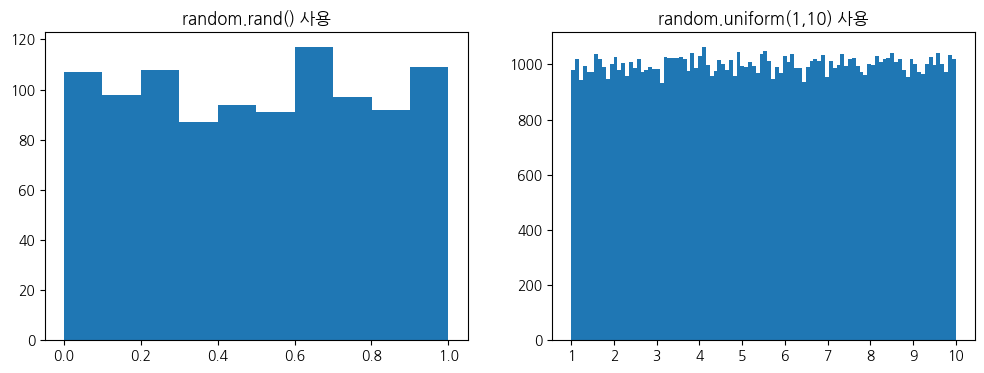

In [29]:
plt.figure(figsize=(12,4))

# rand() 사용
plt.subplot(1,2,1)
data1 = np.random.rand(1000)
plt.title('random.rand() 사용')
plt.hist(data1, bins=10)

# uniform() 사용
plt.subplot(1,2,2)
data2 = np.random.uniform(1,10,100000)
# 100000개의 data를 100개 구간으로 분포
plt.hist(data2, bins=100)    # 그래프상에 균등 분포를 보여줌
plt.xticks(range(1,11))
plt.title('random.uniform(1,10) 사용')
plt.show()

##### 연속형 확률 분포 : 정규 분포 예제

[[-1.126 -1.35  -0.249]
 [-2.082  0.943 -0.565]]


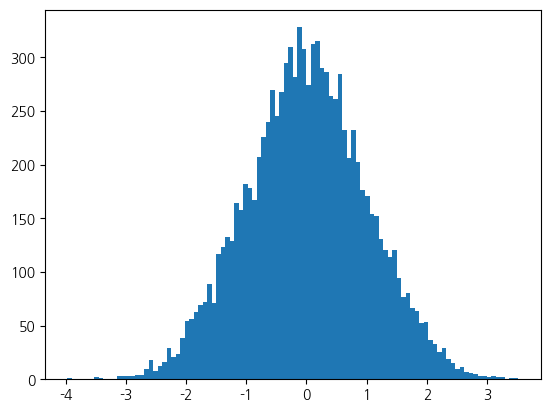

In [30]:
mean = 0    # 평균
std = 1    # 표준편차
a = np.random.normal(mean, std, (2,3))    # 표준 정규 분포
print(a)

data = np.random.normal(mean, std, 10000)
plt.hist(data, bins=100)
plt.show()

##### 연속형 확률 분포 : 지수 분포

[ 1.657  2.245  4.687  1.852  0.087  1.682  0.454  1.248  1.673  2.15
  0.152  3.755  5.759  2.398  1.85   1.929  2.395  4.25   0.326  0.07
  0.148  0.652  1.031  1.253  0.509  0.157  0.572  2.96   1.88   2.698
  1.497  0.588  6.723  3.769  4.833  0.484  2.391  1.588  0.483  3.402
  0.006  0.376  0.364  1.737  1.432  5.301  3.529  0.801  1.504  0.742
  0.449  1.887  3.49   0.061  0.101  0.076  2.419  0.857  2.469  0.504
  0.021  2.186  0.433  1.625  1.138  4.425  0.077  1.183  3.638  2.281
  4.217  9.481  1.628  0.847  0.169  1.979  3.001  1.384  0.459  4.704
  4.524  0.966  2.142  2.937  0.215  3.728  2.638  1.475  5.054  3.076
  1.357  4.199  4.183  1.936  4.347  2.622  0.203  4.189  2.774  0.806
  0.306  0.155  6.638  1.797  0.131  0.05   0.228  2.307  0.47   1.448
  3.565  2.922  1.02   3.693  0.74   0.567  2.802  1.374  5.909  0.631
  1.509  0.453  0.167  0.416  0.122  0.447  0.046  0.294  1.134  0.653
  0.798  0.375  5.347  4.512  0.804  4.987  1.156  0.701  9.141  1.124
  0.175 

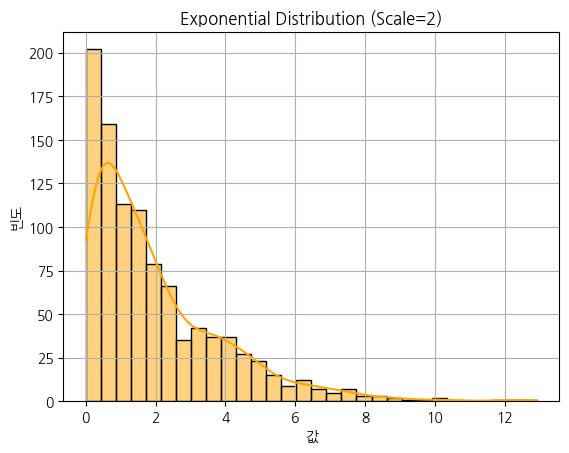

In [31]:
# 평균 2분마다 전화가 걸려오는 상황, 1000개의 샘플
scale = 2
data = np.random.exponential(scale=scale, size=1000)
print(data)

sns.histplot(data, bins=30, kde=True, color='orange', edgecolor='black')
plt.title(f'Exponential Distribution (Scale={scale})')
plt.xlabel('값')
plt.ylabel('빈도')
plt.grid(True)
plt.show()

##### 표본 추출(Sampling) #1

In [32]:
# 전체 데이터 (모집단)
population = np.arange(1,11)    # 1부터 10까지

# 단순 무작위 표본 : replace=False(중복 불가)
np.random.seed(123)
simple_sample = np.random.choice(population, size=10, replace=False)    # 비복원 추출 : 중복 불가
print('단순 무작위 표본:', simple_sample)

# 복원 추출: replac=True(중복 가능)
with_replacement = np.random.choice(population, size=10, replace=True)    # 복원 추출 : 중복 허용
print('복원 추출:', with_replacement)

단순 무작위 표본: [ 5  1  8  6  9  4  2  7 10  3]
복원 추출: [ 2  1  2 10  1  1 10  4  5  1]


##### 표본 추출(Sampling) #2

In [33]:
sample = np.arange(1,101)    # 1부터 100까지
# 가중 표본 추출
weights = np.linspace(0.5,2.0,100)    # 뒤쪽 숫자에 더 높은 가중치
p_array = weights/np.sum(weights)
print(f'가중치 합: {np.sum(p_array)}')    # 가중치의 합은 무조건 1이 되어야 함

weighted_sample = np.random.choice(sample, size=10,
                                   p=weights/np.sum(weights))    # 1~100까지의 숫자 중 1개 선택(가중치 부여)
print('가중 표본:', weighted_sample)

# 배열 섞기
shuffled = sample.copy()
np.random.shuffle(shuffled)
print('셔플 10개:', shuffled[:10])

arr = np.random.sample(5)    # 0~1 사이의 난수 반환
print(f'sample(5): {arr}')    # [0.357, 0.806, ...]

arr = np.random.sample((2,3))
print(f'sample(2,3):\n {arr}')

arr = np.random.randint(1,10,size=4)
print(f'randint(): {arr}')    # [3 7 1 9] 등

가중치 합: 1.0
가중 표본: [72 75 59 17 81 58 45 64 83 51]
셔플 10개: [ 8 33  3 46 32 79 75 36  5 74]
sample(5): [0.38  0.549 0.557 0.004 0.638]
sample(2,3):
 [[0.058 0.043 0.875]
 [0.293 0.763 0.368]]
randint(): [9 7 2 7]


##### 중심 극한 정리(Central Limit Theorem)

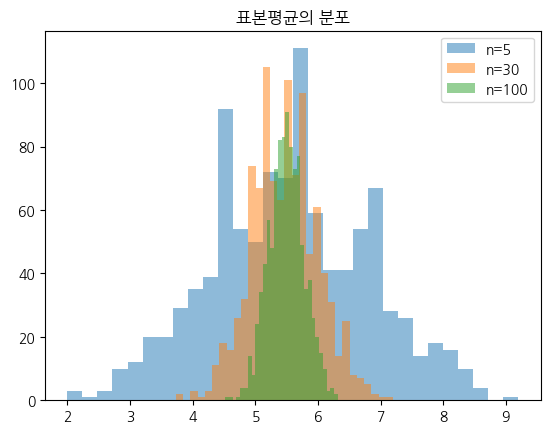

In [34]:
population = np.arange(1,11)

def sample_means(n,trials=1000):
    means = [np.mean(np.random.choice(population, size=n)) for _ in range(trials)]
    return means

for n in [5,30,100]:
    means = sample_means(n)
    plt.hist(means, bins=30, alpha=0.5, label=f'n={n}')

plt.legend()
plt.title('표본평균의 분포')
plt.show()